# Retail Sales Data Analysis

## Final Capstone Project

This project analyses retail sales transaction data from four South African store branches.

My goal is to clean the dataset, calculate revenue, analyse sales performance, create visualisations, and use the results to make practical business recommendations.

The dataset is synthetic and was created for the Melsoft Academy final capstone project.

## 1. Import Libraries

I will begin by importing the libraries needed for the analysis.

- Pandas will be used to load, clean and analyse the sales data.
- Matplotlib will be used later to create charts and visualise the results.

In [121]:
import pandas as pd
import matplotlib.pyplot as plt

from helpers import revenue_by_group, save_chart

## 2. Load the Dataset

I will now load the original sales data from the data folder into a Pandas DataFrame.

I am keeping the original CSV unchanged because all data cleaning must be performed in Python.

In [122]:
df = pd.read_csv("data/sales_data.csv")

In [123]:
df.head()

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
0,2026-01-31,T1000,P006,Full Cream Milk 2L,Dairy,Sandton,9.0,34.0,Cash
1,2026-06-03,T1001,P010,Beef Mince 1kg,Meat,Pretoria,9.0,135.0,Mobile
2,2026-05-31,T1002,P008,Tomatoes 1kg,Produce,Sandton,4.0,30.0,Card
3,2026-01-29,T1003,P005,Cheddar Cheese 500g,Dairy,Sandton,14.0,95.0,Mobile
4,2026-01-03,T1004,P008,Tomatoes 1kg,Produce,Soweto,11.0,30.0,Cash


In [124]:
df.shape

(600, 9)

## 3. Initial Data Inspection

Before cleaning the dataset, I will inspect its structure, data types, missing values, duplicate rows and inconsistent values.

This helps me understand the quality of the raw data before making any changes.

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            600 non-null    object 
 1   transaction_id  600 non-null    object 
 2   product_id      600 non-null    object 
 3   product_name    600 non-null    object 
 4   category        600 non-null    object 
 5   store           600 non-null    object 
 6   quantity        599 non-null    float64
 7   unit_price      600 non-null    object 
 8   payment_method  600 non-null    object 
dtypes: float64(1), object(8)
memory usage: 42.3+ KB


In [126]:
df.isnull().sum()

date              0
transaction_id    0
product_id        0
product_name      0
category          0
store             0
quantity          1
unit_price        0
payment_method    0
dtype: int64

In [127]:
df.duplicated().sum()

np.int64(1)

In [128]:
df["category"].unique()

array(['Dairy', 'Meat', 'Produce', 'Beverages', 'Bakery', 'beverages'],
      dtype=object)

In [129]:
df["store"].unique()

array(['Sandton', 'Pretoria', 'Soweto', 'Rosebank', '  soweto '],
      dtype=object)

### Specific Data-Quality Checks

The initial inspection showed missing data, a duplicate row and inconsistent text values.

I will now investigate the remaining known data-quality problems before cleaning the dataset.

In [130]:
pd.to_numeric(df["unit_price"], errors="coerce").isnull().sum()

np.int64(1)

In [131]:
df[pd.to_numeric(df["unit_price"], errors="coerce").isnull()]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
42,2026-01-12,T1042,P009,Chicken Breasts 1kg,Meat,Sandton,15.0,unknown,Mobile


In [132]:
df[df["quantity"] < 0]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
200,2026-02-12,T1200,P009,Chicken Breasts 1kg,Meat,Soweto,-3.0,120.0,Mobile


In [133]:
standard_dates = pd.to_datetime(
    df["date"],
    format="%Y-%m-%d",
    errors="coerce"
)

df[standard_dates.isnull()]

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method
120,03/15/2026,T1120,P003,Whole Wheat Bread,Bakery,Soweto,1.0,28.0,EFT


## 4. Data Cleaning

I identified several data-quality problems in the raw dataset.

I will now clean a copy of the original DataFrame so that the raw data remains unchanged.

The cleaning process will handle missing quantities, non-numeric prices, negative quantities, duplicate rows, inconsistent date formats and inconsistent text values.

In [134]:
df_clean = df.copy()

starting_rows = len(df_clean)

print("Starting rows:", starting_rows)

Starting rows: 600


### Missing Quantity

A transaction with no quantity cannot be used reliably because revenue depends on the number of units sold.

I will count the missing quantity values and remove those rows.

In [135]:
missing_quantity = df_clean["quantity"].isnull().sum()

print("Missing quantity rows:", missing_quantity)

df_clean = df_clean.dropna(subset=["quantity"])

Missing quantity rows: 1


In [136]:
df_clean.shape

(599, 9)

### Invalid Unit Price

The unit_price column should contain numeric values, but the raw data contains a non-numeric value.

I will convert the column to numeric values. Any value that cannot be converted will become missing and will then be removed.

In [137]:
df_clean["unit_price"] = pd.to_numeric(
    df_clean["unit_price"],
    errors="coerce"
)

invalid_price = df_clean["unit_price"].isnull().sum()

print("Invalid unit price rows:", invalid_price)

df_clean = df_clean.dropna(subset=["unit_price"])

Invalid unit price rows: 1


In [138]:
df_clean.shape

(598, 9)

### Negative Quantity

A normal sales transaction cannot contain a negative quantity.

I will identify and remove any rows where the quantity is below zero.

In [139]:
negative_quantity = (df_clean["quantity"] < 0).sum()

print("Negative quantity rows:", negative_quantity)

df_clean = df_clean[df_clean["quantity"] >= 0]

Negative quantity rows: 1


In [140]:
df_clean.shape

(597, 9)

### Duplicate Transactions

Duplicate rows can cause sales and revenue to be counted more than once.

I will count and remove exact duplicate rows.

In [141]:
duplicate_rows = df_clean.duplicated().sum()

print("Duplicate rows:", duplicate_rows)

df_clean = df_clean.drop_duplicates()

Duplicate rows: 1


In [142]:
df_clean.shape

(596, 9)

### Date Formatting

The dataset contains a date that uses a different format from the others.

I will convert the entire date column into Pandas datetime values so that all dates are interpreted correctly before I perform any monthly analysis.

In [143]:
df_clean["date"] = pd.to_datetime(
    df_clean["date"],
    format="mixed",
    errors="coerce"
)

print("Invalid dates after conversion:", df_clean["date"].isnull().sum())

Invalid dates after conversion: 0


In [144]:
df_clean["date"].head()

0   2026-01-31
1   2026-06-03
2   2026-05-31
3   2026-01-29
4   2026-01-03
Name: date, dtype: datetime64[ns]

### Inconsistent Text Values

Some text values contain inconsistent capitalisation or extra spaces.

For example, "beverages" should be grouped with "Beverages", while "  soweto " should be grouped with "Soweto".

I will remove unnecessary spaces and standardise the capitalisation of the relevant text columns.

In [145]:
text_columns = ["category", "store", "payment_method"]

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip().str.title()

In [146]:
print("Categories:")
print(df_clean["category"].unique())

print("\nStores:")
print(df_clean["store"].unique())

print("\nPayment methods:")
print(df_clean["payment_method"].unique())

Categories:
['Dairy' 'Meat' 'Produce' 'Beverages' 'Bakery']

Stores:
['Sandton' 'Pretoria' 'Soweto' 'Rosebank']

Payment methods:
['Cash' 'Mobile' 'Card' 'Eft']


### Cleaning Verification

I will perform final checks to confirm that the major data-quality problems have been removed or corrected successfully.

In [147]:
print("Clean dataset shape:", df_clean.shape)
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Negative quantities:", (df_clean["quantity"] < 0).sum())

Clean dataset shape: (596, 9)
Missing values: 0
Duplicate rows: 0
Negative quantities: 0


### Data Quality Report

I will summarise the cleaning process so that there is a clear record of the problems found, the rows removed and the final number of usable transactions.

In [148]:
final_rows = len(df_clean)
total_removed = starting_rows - final_rows

print("=" * 40)
print("DATA QUALITY REPORT")
print("=" * 40)

print(f"Starting rows:              {starting_rows}")
print(f"Missing quantity removed:   {missing_quantity}")
print(f"Invalid price removed:      {invalid_price}")
print(f"Negative quantity removed:  {negative_quantity}")
print(f"Duplicate rows removed:     {duplicate_rows}")
print("-" * 40)
print(f"Total rows removed:         {total_removed}")
print(f"Clean rows remaining:       {final_rows}")

print("=" * 40)

DATA QUALITY REPORT
Starting rows:              600
Missing quantity removed:   1
Invalid price removed:      1
Negative quantity removed:  1
Duplicate rows removed:     1
----------------------------------------
Total rows removed:         4
Clean rows remaining:       596


### Cleaning Summary

I started with 600 sales transactions. I removed four unusable rows: one with a missing quantity, one with an invalid unit price, one with a negative quantity and one exact duplicate.

I also corrected the inconsistent date format and standardised inconsistent text values instead of removing those transactions.

After cleaning, I was left with 596 valid transactions that can now be used for the sales analysis.

## 5. Revenue Calculation and Descriptive Analysis

Now that the dataset has been cleaned, I can begin analysing the sales data.

The original dataset does not contain a revenue column, so I will calculate revenue for each transaction by multiplying the quantity sold by the unit price.

In [149]:
df_clean["revenue"] = df_clean["quantity"] * df_clean["unit_price"]

In [150]:
df_clean.head()

,date,transaction_id,product_id,product_name,category,store,quantity,unit_price,payment_method,revenue
0,2026-01-31,T1000,P006,Full Cream Milk 2L,Dairy,Sandton,9.0,34.0,Cash,306.0
1,2026-06-03,T1001,P010,Beef Mince 1kg,Meat,Pretoria,9.0,135.0,Mobile,1215.0
2,2026-05-31,T1002,P008,Tomatoes 1kg,Produce,Sandton,4.0,30.0,Card,120.0
3,2026-01-29,T1003,P005,Cheddar Cheese 500g,Dairy,Sandton,14.0,95.0,Mobile,1330.0
4,2026-01-03,T1004,P008,Tomatoes 1kg,Produce,Soweto,11.0,30.0,Cash,330.0


In [151]:
df_clean.shape

(596, 10)

### 5.1 Total Revenue

I will calculate the total revenue generated across all four stores using the cleaned sales data.

In [152]:
total_revenue = df_clean["revenue"].sum()

print(f"Total revenue: R{total_revenue:,.2f}")

Total revenue: R324,303.00


**Interpretation:**  
After cleaning the dataset, I found that the 596 valid sales transactions generated a total revenue of **R324,303.00** across all four stores.

This gives me the overall sales value for the period covered by the dataset and provides a baseline that I can use to compare the performance of individual categories, products and stores.

### 5.2 Revenue by Category

I will group the cleaned sales data by product category and calculate the total revenue generated by each category.

I will then rank the categories from highest to lowest revenue to see which parts of the business contribute the most sales value.

In [153]:
category_revenue = revenue_by_group(df_clean, "category")

category_revenue

category
Beverages    109320.0
Meat         104055.0
Dairy         65604.0
Produce       22806.0
Bakery        22518.0
Name: revenue, dtype: float64

In [154]:
for category, revenue in category_revenue.items():
    print(f"{category}: R{revenue:,.2f}")

Beverages: R109,320.00
Meat: R104,055.00
Dairy: R65,604.00
Produce: R22,806.00
Bakery: R22,518.00


**Interpretation:**  
Beverages generated the highest revenue at **R109,320.00**, followed closely by Meat at **R104,055.00**.

Dairy generated **R65,604.00**, while Produce and Bakery were much lower at **R22,806.00** and **R22,518.00** respectively.

This shows that Beverages and Meat are the strongest revenue-generating categories in this dataset. However, revenue alone does not tell me whether Beverages leads because it sells more units or because its products are more expensive. I will investigate that later in the critical-thinking section.

### 5.3 Revenue by Store

I will calculate the total revenue generated by each store and rank the stores from highest to lowest.

This will allow me to identify the highest-performing and lowest-performing branches based on revenue.

In [155]:
store_revenue = revenue_by_group(df_clean, "store")

store_revenue

store
Sandton     89137.5
Pretoria    84412.0
Soweto      83569.0
Rosebank    67184.5
Name: revenue, dtype: float64

In [156]:
for store, revenue in store_revenue.items():
    print(f"{store}: R{revenue:,.2f}")

Sandton: R89,137.50
Pretoria: R84,412.00
Soweto: R83,569.00
Rosebank: R67,184.50


**Interpretation:**  
Sandton generated the highest revenue at **R89,137.50**, while Rosebank generated the lowest revenue at **R67,184.50**.

Pretoria and Soweto performed relatively close to Sandton, generating **R84,412.00** and **R83,569.00** respectively.

This shows that Sandton was the strongest store by revenue during the period covered by the dataset. However, I would not make an investment decision based on revenue alone because I would also want to understand factors such as customer numbers, operating costs, profitability and growth potential.

### 5.4 Best-Selling Product vs Highest-Earning Product

I will compare product performance in two different ways.

First, I will identify the product that sold the highest total quantity. Then I will identify the product that generated the highest total revenue.

This comparison will help me understand the difference between sales volume and sales value.

In [157]:
product_quantity = (
    df_clean.groupby("product_name")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

product_quantity

product_name
Rooibos Tea 100g       570.0
Full Cream Milk 2L     566.0
Cheddar Cheese 500g    488.0
Bananas 1kg            464.0
Croissant              452.0
Chicken Breasts 1kg    443.0
Whole Wheat Bread      441.0
Coffee Beans 1kg       432.0
Tomatoes 1kg           396.0
Beef Mince 1kg         377.0
Name: quantity, dtype: float64

In [158]:
print("Best-selling product by quantity:")
print(f"{product_quantity.index[0]}: {product_quantity.iloc[0]:,.0f} units")

Best-selling product by quantity:
Rooibos Tea 100g: 570 units


In [159]:
product_revenue = (
    df_clean.groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

product_name
Coffee Beans 1kg       77760.0
Chicken Breasts 1kg    53160.0
Beef Mince 1kg         50895.0
Cheddar Cheese 500g    46360.0
Rooibos Tea 100g       31350.0
Full Cream Milk 2L     19244.0
Whole Wheat Bread      12348.0
Tomatoes 1kg           11880.0
Bananas 1kg            11136.0
Croissant              10170.0
Name: revenue, dtype: float64

In [160]:
print("Highest-earning product by revenue:")
print(f"{product_revenue.index[0]}: R{product_revenue.iloc[0]:,.2f}")

Highest-earning product by revenue:
Coffee Beans 1kg: R77,760.00


**Interpretation:**  
Rooibos Tea 100g was the best-selling product by quantity, with **570 units sold**, while Coffee Beans 1kg generated the highest revenue at **R77,760.00**.

This shows that the product selling the most units is not necessarily the product making the most money. Rooibos Tea performs strongly in terms of sales volume, while Coffee Beans generates more revenue because each unit has a higher selling price.

This difference is important because it shows the business should consider both quantity sold and revenue generated when evaluating product performance.

### 5.5 Revenue by Month

I will analyse revenue month by month to identify how sales performance changed over the period covered by the dataset.

Because I converted the date column to a proper datetime format during cleaning, I can now safely group transactions by month.

In [161]:
df_clean["month"] = df_clean["date"].dt.to_period("M")

monthly_revenue = (
    df_clean.groupby("month")["revenue"]
    .sum()
    .sort_index()
)

monthly_revenue

month
2026-01    44140.0
2026-02    47411.5
2026-03    37588.0
2026-04    57409.0
2026-05    77000.0
2026-06    58026.5
2026-07     2728.0
Freq: M, Name: revenue, dtype: float64

In [162]:
for month, revenue in monthly_revenue.items():
    print(f"{month}: R{revenue:,.2f}")

2026-01: R44,140.00
2026-02: R47,411.50
2026-03: R37,588.00
2026-04: R57,409.00
2026-05: R77,000.00
2026-06: R58,026.50
2026-07: R2,728.00


In [163]:
print("Earliest transaction:", df_clean["date"].min())
print("Latest transaction:", df_clean["date"].max())

Earliest transaction: 2026-01-01 00:00:00
Latest transaction: 2026-07-01 00:00:00


In [164]:
monthly_transactions = df_clean.groupby("month").size()

for month, transactions in monthly_transactions.items():
    print(f"{month}: {transactions} transactions")

2026-01: 93 transactions
2026-02: 83 transactions
2026-03: 90 transactions
2026-04: 109 transactions
2026-05: 119 transactions
2026-06: 97 transactions
2026-07: 5 transactions


**Interpretation:**  
Monthly revenue was uneven rather than consistently increasing or decreasing.

Revenue increased from **R44,140.00 in January** to **R47,411.50 in February**, before falling to **R37,588.00 in March**. It then increased strongly to **R57,409.00 in April** and reached its highest level of **R77,000.00 in May**, before decreasing to **R58,026.50 in June**.

July shows only **R2,728.00**, but I would not interpret this as a major decline in business performance. The dataset only contains **5 transactions on 1 July**, meaning July is an incomplete month and cannot fairly be compared with the complete months.

Overall, the monthly pattern is uneven, with May performing especially strongly. The business should investigate what contributed to the increase in April and May, as well as the lower performance in March and June. Possible factors such as promotions, seasonal demand, store performance or changes in product mix would require additional data before I could determine the cause.

In [165]:
text_columns = ["category", "store", "payment_method"]

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip().str.title()

In [166]:
df_clean["payment_method"] = df_clean["payment_method"].replace({"Eft": "EFT"})

In [167]:
text_columns = ["category", "store", "payment_method"]

for column in text_columns:
    df_clean[column] = df_clean[column].str.strip().str.title()

df_clean["payment_method"] = df_clean["payment_method"].replace({"Eft": "EFT"})

### 5.6 Average Transaction Value and Payment Method

I will calculate the average value of a transaction using the revenue generated by each cleaned transaction.

I will also identify the most frequently used payment method to understand how customers most commonly paid for their purchases.

In [168]:
average_transaction_value = df_clean["revenue"].mean()

print(f"Average transaction value: R{average_transaction_value:,.2f}")

Average transaction value: R544.13


In [169]:
payment_counts = df_clean["payment_method"].value_counts()

payment_counts

payment_method
Mobile    166
EFT       144
Cash      143
Card      143
Name: count, dtype: int64

In [170]:
most_common_payment = payment_counts.index[0]
most_common_payment_count = payment_counts.iloc[0]

print(f"Most common payment method: {most_common_payment}")
print(f"Number of transactions: {most_common_payment_count}")

Most common payment method: Mobile
Number of transactions: 166


**Interpretation:**  
The average transaction generated **R544.13** in revenue.

This means that across the 596 valid transactions, a typical transaction was worth about R544 in sales revenue.

Mobile was the most commonly used payment method, appearing in **166 transactions**. However, the payment methods were distributed fairly evenly, with EFT used 144 times and both Cash and Card used 143 times.

This suggests that customers use a mixture of payment methods rather than relying heavily on one option, although Mobile had a slight lead.

## 6. Data Visualisation

I will now create charts to make the main sales findings easier to understand.

The first chart compares total revenue across the five product categories.

### 6.1 Revenue by Category

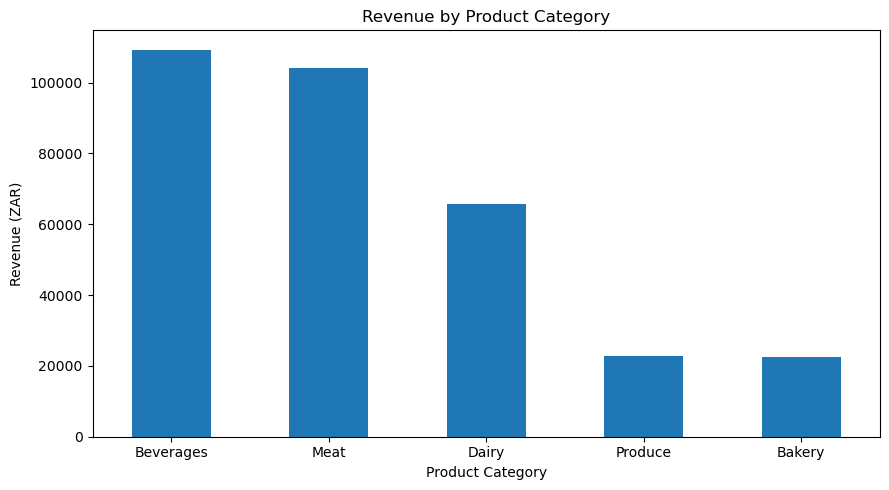

In [179]:
fig, ax = plt.subplots(figsize=(9, 5))

category_revenue.plot(kind="bar", ax=ax)

ax.set_title("Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Revenue (ZAR)")

ax.tick_params(axis="x", rotation=0)

fig.tight_layout()

save_chart(fig, "revenue_by_category.png")

plt.show()

In [172]:
plt.savefig("charts/revenue_by_category.png", dpi=300)

<Figure size 640x480 with 0 Axes>

### 6.2 Revenue by Store

This chart compares the total revenue generated by each store branch.

It makes it easier to see which branches generated the highest and lowest revenue during the period covered by the dataset.

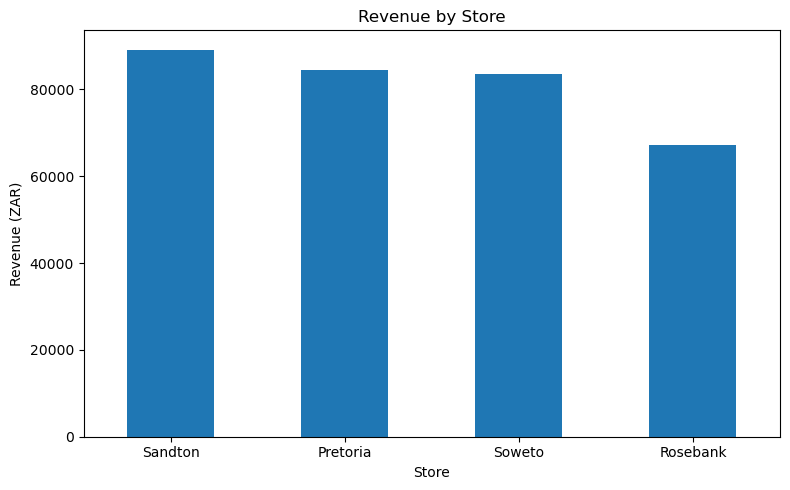

In [173]:
fig, ax = plt.subplots(figsize=(8, 5))

store_revenue.plot(kind="bar", ax=ax)

ax.set_title("Revenue by Store")
ax.set_xlabel("Store")
ax.set_ylabel("Revenue (ZAR)")

ax.tick_params(axis="x", rotation=0)

fig.tight_layout()

save_chart(fig, "revenue_by_store.png")

plt.show()

### 6.3 Revenue by Month

This line chart shows how total revenue changed from month to month across the period covered by the dataset.

It helps me identify changes in sales performance over time and highlights the unusually low July value, which is caused by July containing only a small number of transactions.

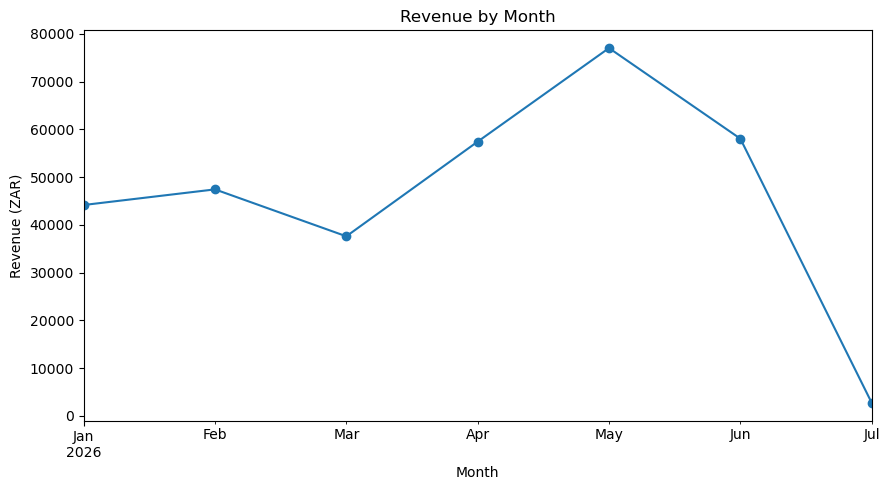

In [174]:
fig, ax = plt.subplots(figsize=(9, 5))

monthly_revenue.plot(kind="line", marker="o", ax=ax)

ax.set_title("Revenue by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (ZAR)")

ax.tick_params(axis="x", rotation=0)

fig.tight_layout()

save_chart(fig, "revenue_by_month.png")

plt.show()

## 7. Critical Thinking and Business Insights

The descriptive analysis shows what happened in the sales data, but I now want to understand what the results mean for the business.

In this section, I will use the cleaned data to investigate product performance, category performance, monthly trends and store performance before making recommendations.

In [175]:
product_comparison = (
    df_clean.groupby("product_name")
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_unit_price=("unit_price", "mean")
    )
)

product_comparison.loc[
    ["Rooibos Tea 100g", "Coffee Beans 1kg"]
]

,total_quantity,total_revenue,average_unit_price
product_name,,,
Rooibos Tea 100g,570.0,31350.0,55.0
Coffee Beans 1kg,432.0,77760.0,180.0


### 7.1 Volume vs Price

Rooibos Tea 100g sold the highest quantity at **570 units**, but it generated only **R31,350.00** in revenue because its unit price is **R55.00**.

Coffee Beans 1kg sold fewer units at **432 units**, but generated **R77,760.00** because its unit price is much higher at **R180.00**.

This shows that high sales volume does not automatically mean high revenue. A lower-priced product may sell many units but still generate less revenue than a higher-priced product selling fewer units.

For the business, this means product performance should not be judged using quantity alone. High-volume products can be important for customer demand and turnover, while higher-priced products can make a much larger contribution to revenue.

### 7.2 Why Beverages Leads on Revenue

Beverages generated the highest total revenue in the dataset, so I will compare category revenue, total quantity sold and average unit price to understand why.

In [176]:
category_comparison = (
    df_clean.groupby("category")
    .agg(
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_unit_price=("unit_price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

category_comparison

,total_quantity,total_revenue,average_unit_price
category,,,
Beverages,1009.0,109320.0,108.512397
Meat,820.0,104055.0,127.570093
Dairy,1054.0,65604.0,63.801527
Produce,853.0,22806.0,26.817391
Bakery,893.0,22518.0,25.340164


**Interpretation:**  
Beverages generated the highest category revenue at **R109,320.00**, but it did not sell the highest number of units.

Dairy sold the most units at **1,054**, compared with **1,009 units** for Beverages. However, Dairy's average unit price was much lower at about **R63.80**, while the average unit price for Beverages was about **R108.51**.

Meat had an even higher average unit price of about **R127.57**, but only **820 units** were sold.

This shows that Beverages leads on revenue because it combines relatively high sales volume with relatively high product prices. It is not simply the category with the highest quantity sold.

For the business, this suggests that strong revenue can come from a balance between volume and price rather than relying on only one of them.

### 7.3 Monthly Revenue Trend

I will review the monthly revenue pattern to determine whether revenue is increasing, decreasing or moving unevenly over time.

I will also consider whether the first and last months contain enough data to make a fair comparison.

In [177]:
monthly_summary = pd.DataFrame({
    "revenue": monthly_revenue,
    "transactions": monthly_transactions
})

monthly_summary

,revenue,transactions
month,,
2026-01,44140.0,93
2026-02,47411.5,83
2026-03,37588.0,90
2026-04,57409.0,109
2026-05,77000.0,119
2026-06,58026.5,97
2026-07,2728.0,5


**Interpretation:**  
The monthly revenue trend is **uneven rather than consistently rising or falling**.

Revenue increased from **R44,140.00 in January** to **R47,411.50 in February**, before falling to **R37,588.00 in March**.

It then increased strongly to **R57,409.00 in April** and reached its highest level of **R77,000.00 in May**. Revenue then decreased to **R58,026.50 in June**.

July appears much lower at **R2,728.00**, but this should not be treated as evidence of a sudden collapse in sales. The dataset contains only **5 transactions on 1 July**, so July is an incomplete month and cannot be fairly compared with the complete months.

The business should investigate what caused the stronger performance in April and May and the weaker performance in March and June. Possible areas to investigate include promotions, seasonal demand, product mix and differences in store performance.

The current dataset shows when revenue changed, but it does not contain enough information to prove exactly why those changes happened.

### 7.4 Store Investment Recommendation

I will compare the stores using total revenue, transaction count, average transaction value and units sold before making an investment recommendation.

This gives me a stronger basis for the decision than using revenue alone.

In [178]:
store_summary = (
    df_clean.groupby("store")
    .agg(
        total_revenue=("revenue", "sum"),
        transactions=("transaction_id", "count"),
        average_transaction_value=("revenue", "mean"),
        units_sold=("quantity", "sum")
    )
    .sort_values("total_revenue", ascending=False)
)

store_summary

,total_revenue,transactions,average_transaction_value,units_sold
store,,,,
Sandton,89137.5,153,582.598039,1225.0
Pretoria,84412.0,149,566.523490,1226.0
Soweto,83569.0,159,525.591195,1167.0
Rosebank,67184.5,135,497.662963,1011.0


**Recommendation:**  
Based on the data available, I would recommend **Sandton** as the store for head office to consider investing in.

Sandton generated the highest total revenue at **R89,137.50** and also had the highest average transaction value at approximately **R582.60**. This suggests that Sandton is not only generating strong overall sales, but its individual transactions also tend to be worth more.

However, the other stores show strengths as well. Soweto recorded the highest number of transactions, while Pretoria sold slightly more units than Sandton.

I would therefore treat Sandton as the strongest investment candidate based on the current sales data, but I would not make a final investment decision using revenue alone.

Before committing, I would want additional information such as store operating costs, profit margins, customer numbers, store size, stock availability, local competition and historical growth. These factors would help determine whether Sandton's higher revenue also translates into stronger profitability and long-term potential.

### 7.5 Limitation of the Analysis

One limitation of this analysis is that the dataset contains sales revenue information, but it does not contain business costs or profit data.

This means I can identify which products, categories and stores generate the most revenue, but I cannot determine which ones are actually the most profitable.

For example, Sandton generated the highest revenue, but without information such as rent, salaries, stock costs, utilities and other operating expenses, I cannot say whether Sandton produces the highest profit.

To improve the analysis, I would want to combine the sales data with cost, profit margin, customer and inventory information.